# Project 2: Medical Route Optimization

This notebook demonstrates the Genetic Algorithm solution for the Vehicle Routing Problem (VRP) in a medical delivery context.

In [11]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
import random
from src.models.location import Location
from src.models.vehicle import Vehicle
from src.algorithms.genetic_optimizer import GeneticOptimizer
from src.utils.plotter import Plotter
from src.llm.report_generator import ReportGenerator
from src.utils.data_loader import DataLoader

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# 1. Define Problem Data
depot = Location(0, 50, 50, "Central Depot", type='depot')

NUM_LOCATIONS = 30

locations = DataLoader.load_data(limit=NUM_LOCATIONS, data_dir='../data')

# Create Fleet
# Estimate required capacity
deliveries = [l for l in locations if getattr(l, 'type', 'delivery') == 'delivery']
total_demand = sum(l.demand for l in deliveries)
num_vehicles = 6

fleet = []
total_capacity = 0
total_distance = 0
for i in range(num_vehicles):
    capacity = random.randint(3, 6)
    total_capacity += capacity
    max_distance = random.randint(100, 200)
    total_distance += max_distance
    fleet.append(Vehicle(id=i+1, capacity=capacity, max_distance=max_distance))

print(f"Loaded {NUM_LOCATIONS} locations from dataset and {len(locations) - NUM_LOCATIONS} gas stations.")
print(f"Created Fleet of {len(fleet)} vehicles with total load capacity of {total_capacity} and total autonomy distance of {total_distance}")
print("Fleet: ")
for vehicle in fleet:
    print(f"Vehicle {vehicle.id} has a capacity of {vehicle.capacity} and a max distance of {vehicle.max_distance}")

Loaded 30 locations from dataset and 10 gas stations.
Created Fleet of 6 vehicles with total load capacity of 28 and total autonomy distance of 878
Fleet: 
Vehicle 1 has a capacity of 4 and a max distance of 141
Vehicle 2 has a capacity of 5 and a max distance of 145
Vehicle 3 has a capacity of 4 and a max distance of 142
Vehicle 4 has a capacity of 6 and a max distance of 132
Vehicle 5 has a capacity of 5 and a max distance of 196
Vehicle 6 has a capacity of 4 and a max distance of 122


In [13]:
# 2. Run Genetic Algorithm
# Adjust generations/pop_size based on problem size if needed
locations_times_vehicles = NUM_LOCATIONS * num_vehicles
generations = locations_times_vehicles * 4 
population_size = 60
early_stopping_rounds = 50


optimizer = GeneticOptimizer(locations, depot, fleet, generations=generations, population_size=population_size, early_stopping_rounds=early_stopping_rounds, priority_weight=0.1)
best_routes, best_dist, fitness_history = optimizer.run()

print(f"Best Total Distance: {best_dist:.2f}")

Stopping early at generation 251 due to no improvement for 50 rounds.
Best Total Distance: 1024.89


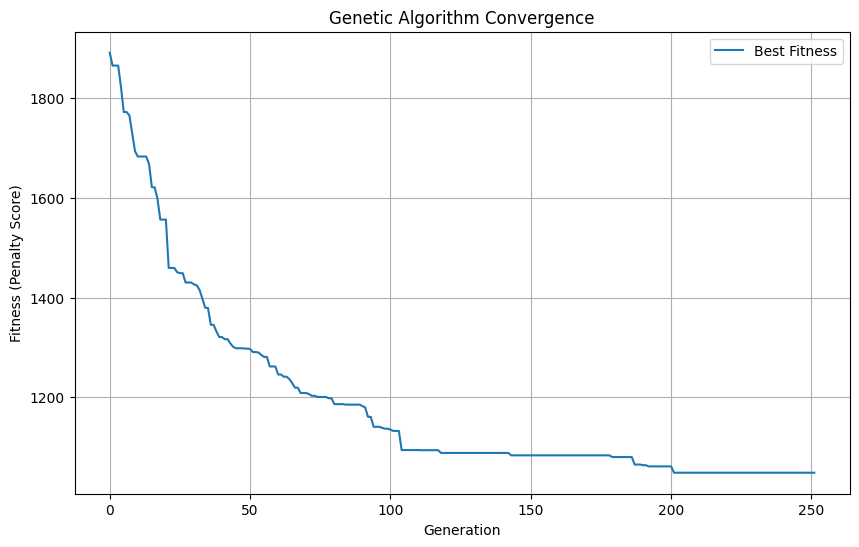

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(fitness_history, label='Best Fitness')
plt.title('Genetic Algorithm Convergence')
plt.xlabel('Generation')
plt.ylabel('Fitness (Penalty Score)')
plt.grid(True)
plt.legend()
plt.show()

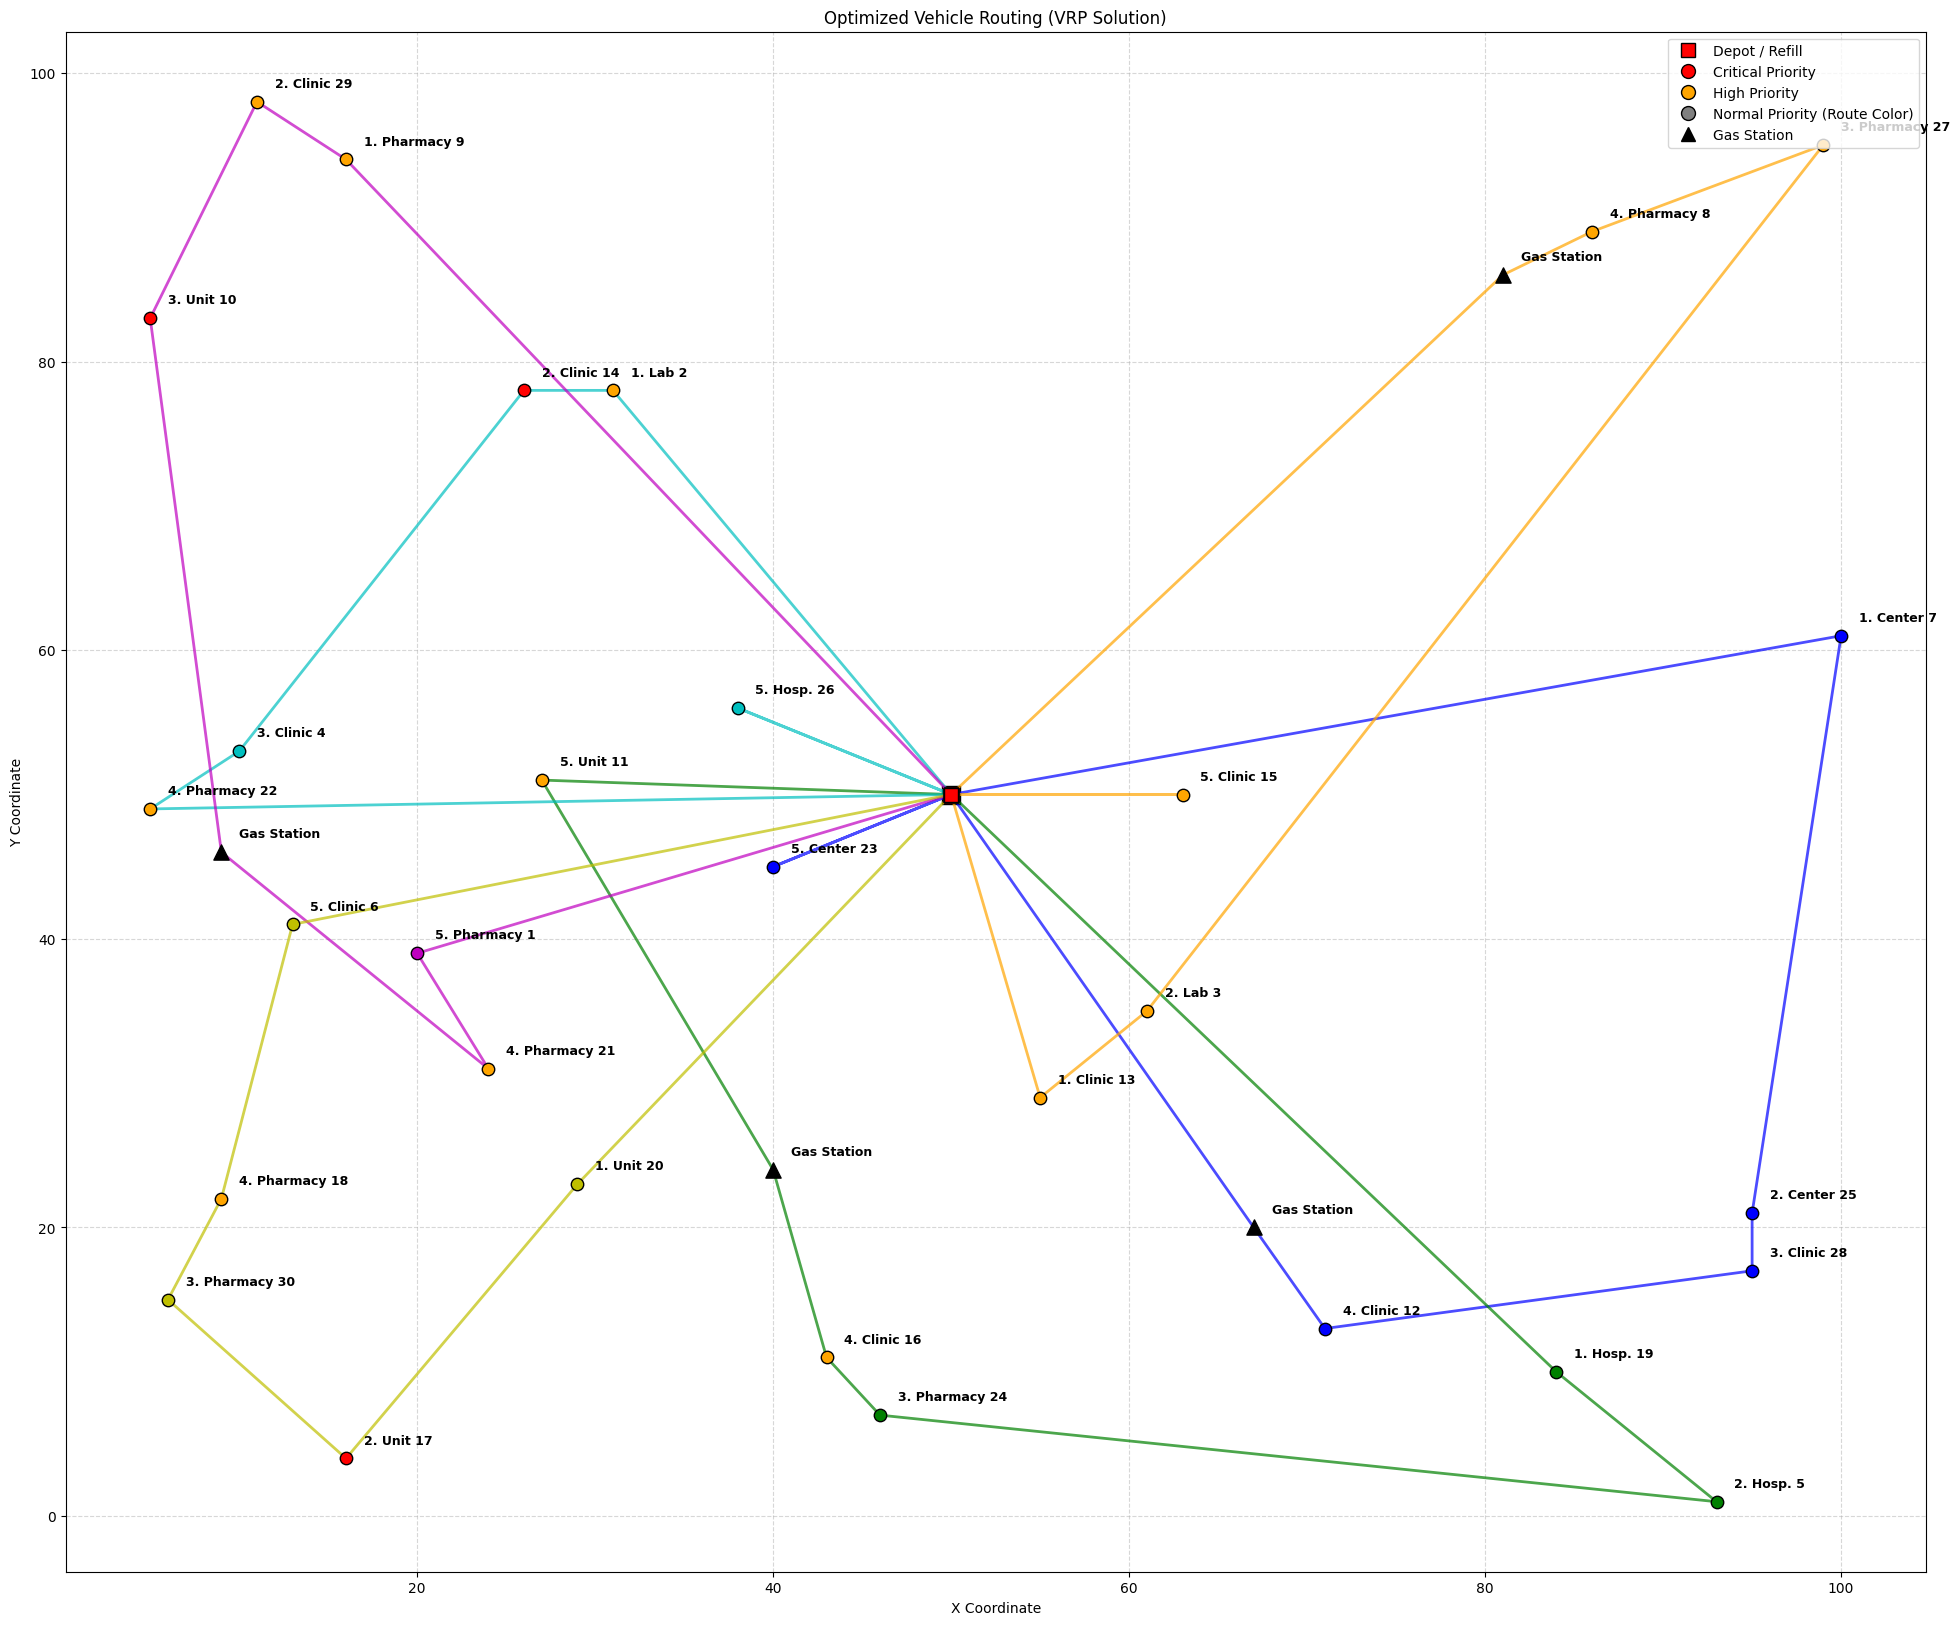

In [15]:
# 3. Visualize Solution
Plotter.plot_solution(best_routes, depot)

In [16]:
# 4. Generate LLM Report
llm = ReportGenerator() # Will use mock if no API key

print("Generating Instructions for Drivers...\n")

max_reports = 10

for i, route in enumerate(best_routes[:max_reports]):
    print(llm.generate_driver_instructions(i, route))
    print("\n" + "="*40 + "\n")

if len(best_routes) > max_reports:
    print(f"... and {len(best_routes) - max_reports} more routes.")

Using cached LLM model.
Generating Instructions for Drivers...

Hey there Driver!

Started the day off right, hit Center 7 (Normal Priority), then moved on to Center 25 (Normal Priority). Next up was Clinic 28 (Normal Priority) and Clinic 12 (Normal Priority). Got some gas at Gas Station 4, stopped by Central Depot, and then headed back for another round hitting Center 23 (Normal Priority). Final stop was back at Central Depot.

Stay safe out there!


Hey Driver,

Good morning! Here's your plan for the day:

- Head to Hosp. 19 at normal priority
- Then go to Hosp. 5 at normal priority
- Next stop is Pharmacy 24 at normal priority
- Then get straight to Clinic 16 at immediate priority
- Gas station 1 next
- Drop off Unit 11 at immediate priority
- Last but not least, head to the Central Depot

Always be safe out there!

G'By


Hey there,

Good day out there! Here’s what you got today:

- Lab 2 (Immediate)
- Clinic 14 (High)
- Clinic 4 (Normal)
- Pharmacy 22 (Immediate)

And let’s not fo